In [1]:
import scanpy as sc

/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWa

In [2]:
import os

In [55]:
preds_adata = os.listdir("/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor")
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_new_cytokine_processed.h5ad")

In [145]:
adata.X = adata.layers["counts"]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# IL-32-beta

In [366]:
ifn_omega = [el for el in preds_adata if ("IL-32-beta" in el and ".h5ad" in el and "81_pred" in el)]

In [367]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [369]:
genes_to_include = ['CD38', 'STAB1', 'SAMD4A', 'STAP1', 'VCAN', 'AHRR', 'ME1', 'RASAL2',
       'IL12RB2', 'FCN1', 'SIGLEC1', 'NRP1', 'MMP9', 'MAP2K6', 'SASH1',
       'SLC16A10', 'IFIT3', 'IFIT2', 'TGFBI', 'TNFSF10', 'EEPD1', 'CDHR3',
       'ADAMDEC1', 'RSAD2', 'CTSL', 'CD36', 'GPNMB', 'BRIP1', 'SLCO2B1',
       'THBS1', 'CYP1B1', 'S100A8', 'PDGFC', 'SLC7A11', 'PID1', 'NEXN',
       'S100A9', 'SEMA6B', 'CXCL10', 'P2RY14', 'CD300E', 'PRR5', 'FPR3',
       'MAFB', 'LINC00937', 'KLF3-AS1', 'LINC01358', 'LINC00996', 'MRC1',
       'ENSG00000285744'] # 50 most variable across donors

In [370]:
genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [371]:
logfold_true = {}
logfold_pred = {}
cytokine="IL-32-beta"

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

/tmp/ipykernel_3287597/4211723727.py:10: RuntimeWarning: invalid value encountered in log2
  logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()


In [372]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.6330312973034133 0.8559897228823841
9
0.475571913785557 0.4118258533818912
5
0.531089494452046 0.9296529643288544
11
0.6306467789747148 0.7895317134654779
8
0.6543544488799641 0.8029143251744131
8
0.5808335633248765 0.49373060254575807
4
0.6135445881969095 0.7710136365722561
8
0.7052106749267378 0.8062701883184036
7
0.7154848436863391 0.856851072287542
10
0.6349462877745258 0.9537368710922226
11
0.7529073165742788 nan
0
0.7485268293177174 0.5646318210330432
1


# BAFF

In [375]:
cytokine = "BAFF"
ifn_omega = [el for el in preds_adata if (cytokine in el and ".h5ad" in el and "81_pred" in el)]

In [376]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [377]:
genes_to_include = ['CD38', 'SAMD4A', 'ST3GAL6', 'IL12RB2', 'SIGLEC1', 'P2RX7', 'PIP5K1B',
       'MAP2K6', 'IFIT3', 'IFIT2', 'TNFSF10', 'SPECC1', 'ADAMDEC1', 'RSAD2',
       'CTSL', 'SLC22A23', 'SLCO5A1', 'MYOF', 'WARS1', 'S100A8', 'PHLDB2',
       'PDGFC', 'ST8SIA6', 'CRIM1', 'FMNL2', 'NFIA', 'NEXN', 'CCDC171', 'ATF5',
       'CXCL10', 'LRRN3', 'LINC02694', 'ZNRF1', 'DYNC2H1', 'SRGAP3', 'SULF2',
       '7SK', 'LINC00937', 'TRGC2', 'SPOPL-DT', 'MIR646HG', 'KLF3-AS1',
       'LINC01358', 'LINC00426', 'TXNDC5', 'TCP10L', 'LINC00996', 'SBF2-AS1',
       'SNHG25', 'ENSG00000285744']

genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [378]:
logfold_true = {}
logfold_pred = {}

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

In [379]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.37323259777651 0.10545503271358865
3
0.4121062842472463 0.14717496791504833
1
0.4014368603523193 0.17387855072624803
2
0.4197743507998858 0.23264233430401227
3
0.34263840905754717 -0.3410451555309058
1
0.14918815850186584 0.4852509976913545
9
0.3325326264417303 0.22069855019189671
3
0.38802480158384606 0.35985391147772045
3
0.3142713918909503 0.330286683723881
6
0.43499662958999186 0.12132246453840022
0
-0.03892094405727418 0.1649628855509612
9
0.16006531205399857 0.3755428797129248
9


# CD27L

In [380]:
cytokine = "CD27L"
ifn_omega = [el for el in preds_adata if (cytokine in el and ".h5ad" in el and "81_pred" in el)]

In [381]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [382]:
genes_to_include = ['STAB1', 'SAMD4A', 'VCAN', 'ST3GAL6', 'FAR2', 'RASAL2', 'SLC1A3',
       'FCN1', 'LPCAT2', 'SIGLEC1', 'NRP1', 'LGMN', 'MMP9', 'NAMPT', 'IFIT3',
       'IFIT2', 'MTHFD1L', 'TGFBI', 'TNFSF10', 'ADAMDEC1', 'RSAD2', 'CTSL',
       'SLC41A2', 'ENPP2', 'SLCO2B1', 'SLCO5A1', 'MYOF', 'WARS1', 'ADAMTS17',
       'IRF8', 'S100A8', 'CREB5', 'SLC7A11', 'PID1', 'NEXN', 'S100A9', 'ATF5',
       'CXCL10', 'P2RY14', 'CALCB', 'CD163', 'ZNRF1', 'LPAR1', '7SK', 'MAFB',
       'LINC00937', 'KLF3-AS1', 'MRC1', 'SNHG25', 'ENSG00000285744']

genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [383]:
logfold_true = {}
logfold_pred = {}

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

In [384]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.8255545813310033 0.6063644365519432
0
0.8496329572604103 0.3345163976722698
0
0.6236285106374304 0.5355216149982717
2
0.8106156097895614 0.48866533069429935
0
0.6967102626711713 0.3699376209887333
0
0.8487346936318492 0.4261226076152295
0
0.8386368870038968 0.3774584745885931
0
0.7503054567311359 0.47635774132349695
1
0.7566219691708234 0.3904643333762106
0
0.7742929215499553 0.6468675881214888
1
0.7785741041749428 0.5462399222980019
1
0.8153240893477751 0.7352386011658484
2


# "ADSF"

In [385]:
cytokine = "ADSF"
ifn_omega = [el for el in preds_adata if (cytokine in el and ".h5ad" in el and "81_pred" in el)]

In [386]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [387]:
genes_to_include = ['CD38', 'STAB1', 'SAMD4A', 'ST3GAL6', 'IL12RB2', 'FCN1', 'P2RX7',
       'NRP1', 'MMP9', 'MAP2K6', 'MS4A6A', 'SLC16A10', 'IFIT3', 'IFIT2',
       'MTHFD1L', 'TNFSF10', 'CDHR3', 'STARD13', 'RSAD2', 'SLC41A2', 'ENPP2',
       'SLC22A23', 'SLCO5A1', 'MYOF', 'WARS1', 'ADAMTS17', 'IRF8', 'S100A8',
       'PDGFC', 'SDK1', 'DAB2', 'PID1', 'FMNL2', 'NEXN', 'S100A9', 'CXCL10',
       'LRRN3', 'P2RY14', 'CALCB', 'LDLRAD3', 'ZNRF1', '7SK', 'LINC00937',
       'KLF3-AS1', 'LINC01358', 'LINC00426', 'TCP10L', 'MRC1',
       'ENSG00000285744', 'ENSG00000287100']

genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [388]:
logfold_true = {}
logfold_pred = {}

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

In [389]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.1156270841383133 0.8352442375244147
11
0.29588634377029693 0.08661986003210531
3
0.23866620039937692 0.5449776804213416
11
0.3516546984752652 0.3498566492585419
6
0.323349464259894 -9.216562929673298e-05
1
0.11350544782025601 0.3032384281459941
8
0.02035408810870034 0.6699067792391651
11
0.29704851551194017 0.5056267096342419
7
0.2437888576525503 0.6177231639522348
9
0.20637771981657413 0.044637434716929936
2
0.14789278286664245 0.3288463427885203
9
0.26164563175635497 0.7528812590552986
11


# "OX40L"

In [390]:
cytokine = "OX40L"
ifn_omega = [el for el in preds_adata if (cytokine in el and ".h5ad" in el and "81_pred" in el)]

In [391]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [392]:
genes_to_include = ['CD38', 'STAB1', 'SAMD4A', 'STAP1', 'VCAN', 'FAR2', 'FCN1', 'NRP1',
       'MMP9', 'NAMPT', 'MAP2K6', 'SLC16A10', 'RGS2', 'IFIT3', 'IFIT2',
       'MTHFD1L', 'TNFSF10', 'EEPD1', 'CDHR3', 'SAT1', 'STARD13', 'RSAD2',
       'BRIP1', 'SLCO5A1', 'ADAMTS17', 'PDGFC', 'SDK1', 'TMEM163', 'PID1',
       'CEP112', 'CHODL', 'EDA', 'NFIA', 'NEXN', 'SEMA6B', 'CXCL10', 'CMTM8',
       'SYNPO2', 'LRRN3', 'P2RY14', 'FUCA1', 'LDLRAD3', 'ZNRF1', 'CD300E',
       'PRR5', '7SK', 'KLF3-AS1', 'LINC01358', 'SNHG25', 'ENSG00000285744']

genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [393]:
logfold_true = {}
logfold_pred = {}

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

In [394]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.4127417022428954 0.4590141189559649
6
0.5237121132521966 0.18909195108245658
1
0.5135821986951904 0.4818171013492677
4
0.2954442381630884 0.05617187158530443
2
0.49794809182555116 0.30908545467956633
1
0.26836106267151005 -0.5556051514101359
0
0.39625730080279625 0.5382718903440259
7
0.2673357817459834 -0.36105868087664106
0
0.5422142797366736 0.35089963228438237
2
0.36584553425926297 -0.06926287356970288
0
0.4689067636610798 0.153735656163082
1
0.3686226559526759 0.7292029836033117
11


# M-CSF

In [395]:
cytokine = "M-CSF"
ifn_omega = [el for el in preds_adata if (cytokine in el and ".h5ad" in el and "81_pred" in el)]

In [396]:
preds = {}
for donor in [f"Donor{i+1}" for i in range(12)]:
    f = [el for el in ifn_omega if f"{donor}_" in el][0]
    bdata = sc.read_h5ad(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor/{f}")
    bdata.var_names = adata.var_names
    preds[donor] = bdata

In [397]:
genes_to_include = ['VCAN', 'RASAL2', 'SLC1A3', 'FCN1', 'NRP1', 'LGMN', 'MMP9', 'RUBCNL',
       'ACP5', 'STEAP1B', 'MS4A6A', 'NRP2', 'IFIT3', 'IFIT2', 'TGFBI', 'EEPD1',
       'STARD13', 'ADAMDEC1', 'RSAD2', 'CTSL', 'CD36', 'GPNMB', 'ENPP2',
       'SLCO2B1', 'SLCO5A1', 'THBS1', 'SLC39A8', 'S100A8', 'PDGFC', 'CRIM1',
       'SLC7A11', 'FRMD4A', 'TMEM163', 'DAB2', 'PID1', 'FMNL2', 'NEXN',
       'S100A9', 'SPRED1', 'P2RY14', 'LDLRAD3', 'CHST15', 'TPRG1', 'SULF2',
       'LPAR1', '7SK', 'MAFB', 'ITSN1', 'LINC00937', 'MSC-AS1']

genes_to_include_mask = [True if g in genes_to_include else False for g in adata.var_names]

In [398]:
logfold_true = {}
logfold_pred = {}

for donor in [f"Donor{i+1}" for i in range(12)]:
    control = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]=="PBS")][:, genes_to_include_mask].X.mean(axis=0)
    perturbed_pred = preds[donor][:, genes_to_include_mask].layers["X_recon"].mean(axis=0)
    perturbed_true = adata[(adata.obs["donor"]==donor) & (adata.obs["cytokine"]==cytokine)][:, genes_to_include_mask].X.mean(axis=0)
    logfold_true[donor] = np.array(np.log2(perturbed_true/control)).squeeze()
    logfold_pred[donor] = np.array(np.log2(perturbed_pred/control)).squeeze()

In [399]:

for d0 in donors:
    scores = []
    for d in donors:
        if d == d0:
            continue
        try:
            scores.append(np.corrcoef((logfold_true[d0], logfold_true[d]))[0,1])
        except:
            continue
    corr_d0 = np.corrcoef((logfold_true[d0], logfold_pred[d0]))[0,1]
    print(np.mean(scores), corr_d0)
    print(sum(x < corr_d0 for x in scores))

0.7755662579387782 0.8021251129322909
6
0.4964511283634186 0.2803092357993957
1
0.7370912920955934 0.6881437170138717
3
0.7157117377038813 0.41294922634882525
0
0.7444278178474832 0.749272523036264
6
0.4884421988761382 0.31693264842344576
1
0.6802493696123227 0.45682240318528655
0
0.7605180782658393 0.6592343914280218
2
0.7775072432364835 0.7748799360592888
4
0.7437190181377314 0.6650680542256823
3
0.7110014052308622 0.8093652622596185
9
0.7970558488408558 0.594693217612732
1


In [319]:
np.corrcoef((logfold_true["Donor8"], logfold_pred["Donor8"]))[0,1]

0.8062701883184036

In [242]:
scores = []
for d in donors:
    if d == "Donor5":
        continue
    scores.append(r2_score(logfold_true["Donor5"], logfold_true[d]))

In [243]:
scores

[0.4699464440345764,
 0.5221140384674072,
 -0.09933054447174072,
 0.2269797921180725,
 0.5966238975524902,
 0.7887281179428101,
 0.8151035308837891,
 0.7563782334327698,
 0.20959454774856567,
 0.6495529413223267,
 0.7442713975906372]

In [241]:
r2_score(logfold_true["Donor5"], logfold_pred["Donor5"])

0.6714459657669067

In [183]:
logfold_true

{'Donor1': array([ 0.28705975,  0.28585765,  0.08103558,  0.11337718, -0.09621788,
        -0.02397925,  0.05618852, -0.00703012, -0.1100825 , -0.2382251 ,
        -0.08710135,  0.10688478, -0.1981115 ,  0.00235235, -0.01736678,
         0.11046403,  0.07400015,  0.10246578,  0.03223848,  0.28404632,
         0.6204387 ,  0.24936506,  0.2677401 , -0.0594396 ,  0.48081633,
         0.42531785, -0.20207316,  0.1480683 ,  0.09475313, -0.48127985,
        -0.144059  , -0.2674745 ,  0.06341252,  0.24963589,  0.0644831 ,
        -0.19808486,  0.02996572, -0.09734759,  0.28926495,  0.43139863,
         0.18443651,  0.2521933 , -0.25100443,  0.03930598,  0.01300893,
         0.34287062,  0.27095684, -0.17789622,  0.10018333,  0.23101355,
        -0.07153792,  0.04369885,  0.7024123 ,  0.04088633, -0.1903973 ,
         0.19127478,  0.44967124,  0.21225338, -0.00399958,  0.07961369,
        -0.10690107,  0.07680631,  0.21559076,  0.00670308, -0.19129737,
        -0.10106506, -0.9404197 ,  0.0323

In [170]:
from scipy.stats import spearmanr
donors = [f"Donor{i+1}" for i in range(12)]

corrs = {}
r2 = {}
spears = {}

for g in range(logfold_true["Donor1"].shape[0]):
    try:
        trues = [logfold_true[d][g] for d in donors]
        predictions = [logfold_pred[d][g] for d in donors]
    
        corrs[g] = np.corrcoef(trues, predictions)[0,1]
        r2[g] = r2_score(trues, predictions)
        spears[g] = spearmanr(trues, predictions)
    except:
        continue

In [171]:
np.nanmean(np.array(list(spears.values())))

0.3480724599134188

In [133]:
import seaborn as sns

<Axes: ylabel='Count'>

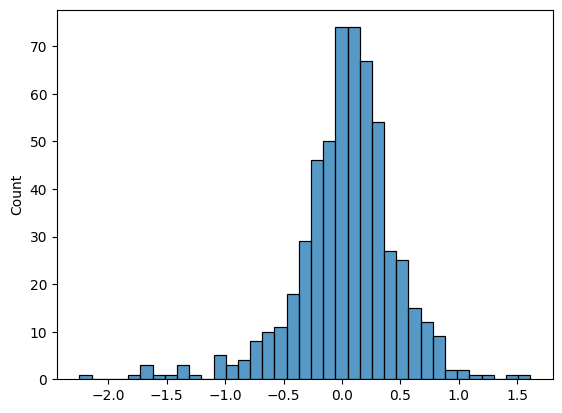

In [134]:
sns.histplot(logfold_true["Donor1"])

<Axes: ylabel='Count'>

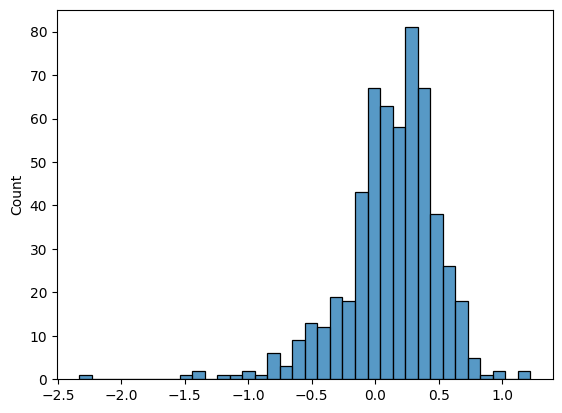

In [137]:
sns.histplot(logfold_true["Donor3"])

<Axes: ylabel='Count'>

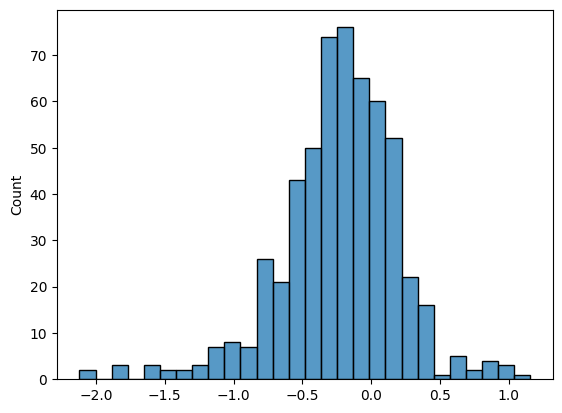

In [140]:
sns.histplot(logfold_pred["Donor4"])

In [85]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

-1.7118214846244864

In [87]:

np.corrcoef(ifit2_true, ifit2_preds)

array([[1.       , 0.6169341],
       [0.6169341, 1.       ]])

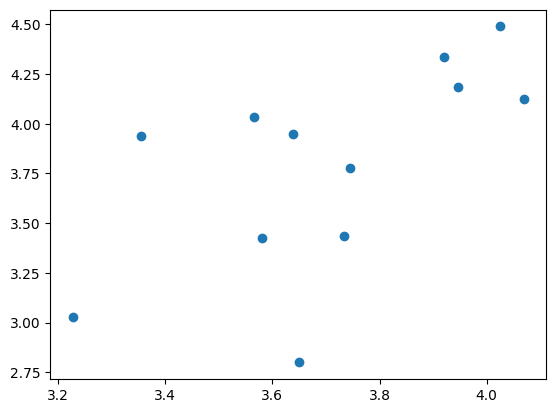

In [80]:
plt.scatter(ifit2_true, ifit2_preds)

In [69]:
adata[(adata.obs["donor"]=="Donor1") & (adata.obs["cytokine"]=="PBS")][:,"IFIT2"].X.mean()

3.1876557

In [70]:
adata[(adata.obs["donor"]=="Donor1") & (adata.obs["cytokine"]=="IFN-omega")][:,"IFIT2"].X.mean()

3.9461684

In [71]:
adata[(adata.obs["donor"]=="Donor1") & (adata.obs["cytokine"]=="PBS")][:,"IFIT2"].X.mean()

3.1876557

In [46]:
preds_adata

['charmed-yogurt-240_Donor9_FasL_9.csv',
 'dandy-aardvark-207_Donor8_IFN-omega_33.csv',
 'kind-frost-150_Donor6_IFN-gamma_2_preds.h5ad',
 'lively-firebrand-172_Donor7_IL-1Ra_2.csv',
 'clean-forest-220_Donor9_BAFF_2_preds.h5ad',
 'colorful-sky-293_Donor12_ADSF_2_preds.h5ad',
 'efficient-dew-262_Donor10_IFN-omega_9_preds.h5ad',
 'denim-puddle-146_Donor5_FasL_81_preds.h5ad',
 'sparkling-dawn-31_Donor1_OX40L_17_preds.h5ad',
 'soft-dawn-266_Donor10_FasL_81.csv',
 'confused-cherry-130_Donor5_OX40L_3.csv',
 'devoted-violet-264_Donor10_IL-1Ra_9_preds.h5ad',
 'faithful-cloud-282_Donor11_CD27L_5.csv',
 'driven-puddle-35_CellFlow.pkl',
 'ethereal-puddle-73_Donor2_BAFF_81_preds.h5ad',
 'charmed-yogurt-240_Donor9_OX40L_9.csv',
 'comfy-hill-76_Donor3_IL-32-beta_2.csv',
 'sparkling-dawn-31_Donor1_OX40L_17.csv',
 'dry-armadillo-120_Donor4_IFN-omega_9.csv',
 'devoted-violet-264_Donor10_IL-1Ra_9.csv',
 'revived-vortex-109_Donor4_OX40L_33_preds.h5ad',
 'dry-armadillo-120_Donor4_M-CSF_9.csv',
 'dazzling-g